# Decision Tree Classification

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('/content/protein.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [6]:
from sklearn.tree import DecisionTreeRegressor
classifier = DecisionTreeRegressor(random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [8]:
print(classifier.predict(sc.transform([[30, 87000, 0, 0, 0, 0, 0, 0, 0]]))) # Updated input with 9 features (placeholders for the last 7)

[44.3903]


In [9]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[37.333  37.5904]
 [29.9339 30.382 ]
 [44.4447 44.4937]
 ...
 [20.7464 21.1112]
 [41.9332 42.0062]
 [36.1336 35.365 ]]


In [11]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 6.40


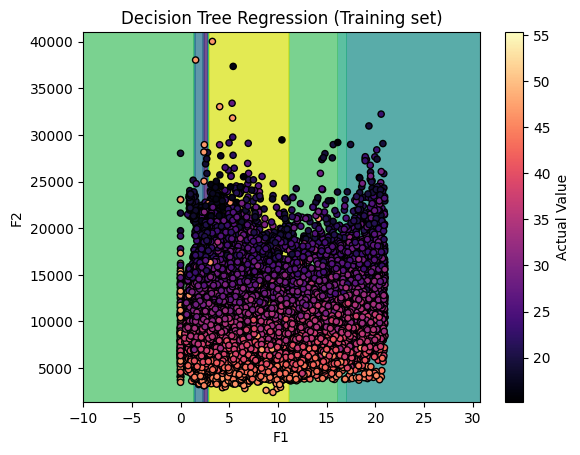

In [13]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))

X_contour_input = np.zeros((X1.size, X_set.shape[1]))
X_contour_input[:, 0] = X1.ravel()
X_contour_input[:, 1] = X2.ravel()

for i in range(2, X_set.shape[1]):
    X_contour_input[:, i] = X_set[:, i].mean()

Z = classifier.predict(sc.transform(X_contour_input)).reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha = 0.75, cmap = plt.cm.viridis)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

scatter = plt.scatter(X_set[:, 0], X_set[:, 1], c = y_set, cmap = plt.cm.magma, edgecolor='k', s=20) # Use continuous cmap for y_set
plt.colorbar(scatter, label='Actual Value')

plt.title('Decision Tree Regression (Training set)')
plt.xlabel('F1')
plt.ylabel('F2')
plt.show()

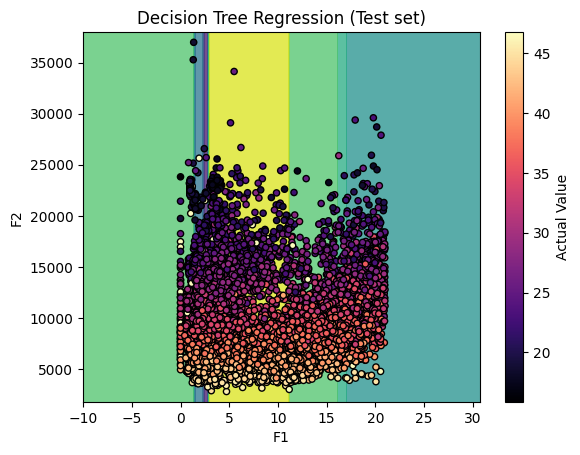

In [14]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))

X_contour_input = np.zeros((X1.size, X_set.shape[1]))
X_contour_input[:, 0] = X1.ravel()
X_contour_input[:, 1] = X2.ravel()

for i in range(2, X_set.shape[1]):
    X_contour_input[:, i] = X_set[:, i].mean()

Z = classifier.predict(sc.transform(X_contour_input)).reshape(X1.shape)

plt.contourf(X1, X2, Z, alpha = 0.75, cmap = plt.cm.viridis)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

scatter = plt.scatter(X_set[:, 0], X_set[:, 1], c = y_set, cmap = plt.cm.magma, edgecolor='k', s=20)
plt.colorbar(scatter, label='Actual Value')

plt.title('Decision Tree Regression (Test set)')
plt.xlabel('F1')
plt.ylabel('F2')
plt.show()